# This demo shows an approach to change model actuators at runtime.

In mujoco all types of actuators are transformed to one unique model. That allows to change actuators to control `position`, `velocity` or `torque` specifically.

Description of the actuation model is available [here](https://mujoco.readthedocs.io/en/latest/computation/index.html#actuation-model).


In [1]:
import mujoco
import mediapy
import gym_lowcostrobot # Import the low-cost robot environments

## We will work and load Koch robot

In [2]:
import gymnasium as gym
from gym_lowcostrobot.envs import LiftCubeCameraEnv
# env = gym.make("LiftCubeCamera-v0", render_mode="rgb_array", observation_mode="both", action_mode="joint")
env = LiftCubeCameraEnv(render_mode="rgb_array", observation_mode="both", action_mode="joint", render_obs=False)
print(env.unwrapped.control_decimation)

40


In [3]:
import numpy as np


class ActuatorMotor:
    def __init__(self) -> None:
        self.dyn = np.array([1, 0, 0])
        self.gain = np.array([1, 0, 0])
        self.bias = np.array([0, 0, 0])

    def __repr__(self) -> str:
        return f"ActuatorMotor(dyn={self.dyn}, gain={self.gain}, bias={self.bias})"


class ActuatorPosition(ActuatorMotor):
    def __init__(self, kp=1, kd=0) -> None:
        super().__init__()
        self.kp = kp
        self.kd = kd
        self.gain[0] = self.kp
        self.bias[1] = -self.kp
        self.bias[2] = -self.kd


class ActuatorVelocity(ActuatorMotor):
    def __init__(self, kv=1) -> None:
        super().__init__()
        self.kv = kv
        self.gain[0] = self.kv
        self.bias[2] = -self.kv


def update_actuator(model, actuator_id, actuator):
    """
    Update actuator in model
    model - mujoco.MjModel
    actuator_id - int or str (name) (for reference see, named access to model elements)
    actuator - ActuatorMotor, ActuatorPosition, ActuatorVelocity
    """

    model.actuator(actuator_id).dynprm[:3] = actuator.dyn
    model.actuator(actuator_id).gainprm[:3] = actuator.gain
    model.actuator(actuator_id).biasprm[:3] = actuator.bias

# Example: set all actuators to "position" control and move to desired position
Here, we try different stiffness and damping settings, and see how it affects the motor's convergence to target joint positions.

In [4]:
model = env.unwrapped.model
data = env.unwrapped.data

torque_motor = ActuatorPosition(kp=1, kd=0)
for actuator_id in range(model.nu):
    update_actuator(model, actuator_id, torque_motor)

# setup simulation
target_q = np.array(
    [
        0.28932849,
        0.92062463,
        -0.9442432,
        -1.02045466,
        1.2824041,
        -0.40766866,
    ]
)

duration = 5  # (seconds)
framerate = 30  # (Hz)
mujoco.mj_resetData(model, data)  # Reset state and time.
obs, info = env.reset()
pixels = env.render()
frames = [pixels]
history_q = [data.qpos[:6].copy()]

while data.time < duration:
    obs, rew, term, trunc, info = env.step(target_q)
    history_q.append(data.qpos[:6].copy())

    if len(frames) < data.time * framerate:
        pixels = env.render()
        frames.append(pixels)
    # print(f"{len(frames)} < {data.time * framerate}", end='\n')
    print(f"Time: {data.time:.4f} < {duration}", end="\r")

mediapy.show_video(frames, fps=framerate)

This browser does not support the video tag.


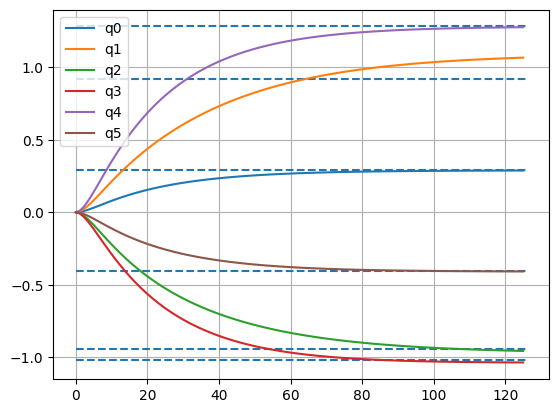

In [5]:
import matplotlib.pyplot as plt

history_q = np.array(history_q)

plt.hlines(target_q, 0, len(history_q), linestyles="dashed")
plt.plot(history_q, label=["q" + str(i) for i in range(6)])
plt.grid()
plt.legend()
plt.show()

In [10]:
model = env.unwrapped.model
data = env.unwrapped.data

torque_motor = ActuatorPosition(kp=10, kd=1)
for actuator_id in range(model.nu):
    update_actuator(model, actuator_id, torque_motor)

# setup simulation
target_q = np.array(
    [
        0.28932849,
        0.92062463,
        -0.9442432,
        -1.02045466,
        1.2824041,
        -0.40766866,
    ]
)

duration = 5  # (seconds)
framerate = 30  # (Hz)
mujoco.mj_resetData(model, data)  # Reset state and time.
obs, info = env.reset()
pixels = env.render()
frames = [pixels]
history_q = [data.qpos[:6].copy()]
actions = []

while data.time < duration:
    obs, rew, term, trunc, info = env.step(target_q)
    history_q.append(data.qpos[:6].copy())
    actions.append(target_q.copy())

    if len(frames) < data.time * framerate:
        pixels = env.render()
        frames.append(pixels)
    # print(f"{len(frames)} < {data.time * framerate}", end='\n')
    print(f"Time: {data.time:.4f} < {duration}", end="\r")

mediapy.show_video(frames, fps=framerate)

This browser does not support the video tag.


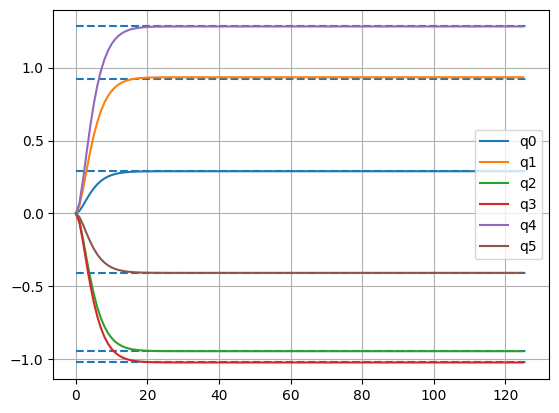

In [11]:
import matplotlib.pyplot as plt

history_q = np.array(history_q)

plt.hlines(target_q, 0, len(history_q), linestyles="dashed")
plt.plot(history_q, label=["q" + str(i) for i in range(6)])
plt.grid()
plt.legend()
plt.show()

# System identification of stiffness and damping
Now, we will identify the system parameters using simulated annealing, given trajectories of our robot.

In [12]:
episode = {'actions':np.array(actions),  'q': np.array(history_q)}

In [32]:
def calc_pose_err_single_ep(episode,  stiffness, damping):
    """
    The episode is a dictionary containing a sequence of joint positions q1...qT and target joint positions, a1...aT. 
    We want to compute the pose error by:
    1) Resetting the environment so that the robot is at the initial joint position q1.
    2) Executing an open-loop policy using a1...aT, while recording the joint positions. 
    3) Comparing the joint positions with the target joint positions to compute the pose error. 
    """


    # Step 1: Reset the environment to the initial joint position q1
    env = LiftCubeCameraEnv(render_mode="rgb_array", observation_mode="both", action_mode="joint", render_obs=False)
    model = env.unwrapped.model
    data = env.unwrapped.data

    torque_motor = ActuatorPosition(kp=stiffness, kd=damping)
    for actuator_id in range(model.nu):
        update_actuator(model, actuator_id, torque_motor)
    
    options = {
        "qpos": np.concatenate([episode['q'][0], [10, 10, 0.01, 1, 0, 0, 0]]),
        "qvel": np.zeros(model.nv),
    }
    obs, _ = env.reset(options=options)
    # pixels = env.render()
    # mediapy.show_image(pixels)
    assert np.allclose(data.qpos[:6], episode['q'][0], atol=1e-3), f"Initial joint position is not correct: {data.qpos[:6]} != {episode['q'][0]}"

    # Step 2: Execute the open-loop policy using a1...aT
    sim_q = []
    for action in episode['actions']:
        env.step(action)
        sim_q.append(data.qpos[:6].copy())
    
    sim_q = np.array(sim_q)

    # Step 3: Compute the pose error
    assert len(episode['q'][1:]) == len(sim_q), f"Number of target joint positions {len(episode['q'][1:])} != number of simulated joint positions {len(sim_q)}"
    pose_err = np.linalg.norm(episode['q'][1:] - sim_q)
    return pose_err
    


In [93]:
# using some random system parameters, we should get high error.
kp = 63
kd = 10
pose_err = calc_pose_err_single_ep(episode, kp, kd)
print(f"kp={kp}, kd={kd}, pose_err={pose_err}")

kp=63, kd=10, pose_err=0.29510328419822934


In [ ]:
# using the true system parameters, we should get 0 error.
kp = 10
kd = 1
pose_err = calc_pose_err_single_ep(episode, kp, kd)
print(f"kp={kp}, kd={kd}, pose_err={pose_err}")

kp=10, kd=1, pose_err=0.0


## Simulated Annealing
Now it is time to optimize our cost function

In [65]:
from simulated_annealing import sa

In [91]:
init_stiffness = np.array([1] * 1)
init_damping = np.array([1] * 1)
stiffness_low = np.array([0] * 1)
stiffness_high = np.array([100] * 1)
damping_low = np.array([0] * 1)
damping_high = np.array([100] * 1)

raw_action_to_stiffness = (
    lambda x: stiffness_low
    + (stiffness_high - stiffness_low) * x
)
raw_action_to_damping = (
    lambda x: damping_low
    + (damping_high - damping_low)
    * x
)

# this is normalized action space.
# init_action = np.array([0.1, 0.01])
init_action = np.array([0.5, 0.5])

def optimize(x):
    kp, kd = x[:1], x[1:]
    kp = raw_action_to_stiffness(kp)[0]
    kd = raw_action_to_damping(kd)[0]
    return calc_pose_err_single_ep(episode, kp, kd)

opt = sa.minimize(
    optimize,
    init_action,
    opt_mode="continuous",
    step_max=1000,
    t_max=100,
    t_min=0,
    bounds=[[0, 1]] * (len(init_stiffness) * 2),
    damping=1.0,
)
opt.results()


+------------------------ RESULTS -------------------------+

      opt.mode: continuous
cooling sched.: linear additive cooling


  initial temp: 100
    final temp: 0.100000
     max steps: 1000
    final step: 1000

  final energy: 0.295103

+-------------------------- END ---------------------------+


In [92]:
recovered_stiffness = raw_action_to_stiffness(opt.best_state[0])[0]
recovered_damping = raw_action_to_damping(opt.best_state[1])[0]
print("end_stiffness", recovered_stiffness)
print("end_damping", recovered_damping)

end_stiffness 63.508869419171035
end_damping 10.732524583863112
